# Pre-02: Metropolis-Hastings MCMC for a One-Point Gaussian Likelihood

We start with the simplest possible MCMC test case: a single measurement $x = 1$ with known uncertainty $\sigma = 0.1$. Assuming a flat prior on $\mu$, the target distribution is proportional to the Gaussian likelihood,

$$
p(\mu \mid x) \propto p(x \mid \mu) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left[-\frac{(\mu - x)^2}{2\sigma^2}\right].
$$

Because the prior is flat, the posterior has the same Gaussian shape as the likelihood. In other words, this is one of the few MCMC exercises where the exact answer is already known analytically: $\mu \mid x \sim \mathcal{N}(1, 0.1^2)$. That makes the notebook a sampler-validation benchmark rather than a realistic scientific inference problem.

Because this posterior is analytically known, it is an ideal benchmark for a hand-written Metropolis-Hastings sampler with a symmetric Gaussian proposal. The proposal ratio cancels, so the Metropolis acceptance log-ratio is just

$$
\log \alpha = \log p(\mu' \mid x) - \log p(\mu^{(t)} \mid x).
$$

The goal here is to verify that the chain reproduces the analytic Gaussian posterior and to inspect the trace of $\mu$ and $\ln P$ as a function of step number.


In [1]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import plot_posterior, plot_trace

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


Metropolis-Hastings builds a Markov chain one step at a time. Starting from the current state $\mu^{(t)}$, the algorithm proposes a trial value $\mu'$ from a proposal distribution $q(\mu'\mid\mu^{(t)})$. Here that proposal is Gaussian and symmetric, so proposing from $\mu^{(t)}$ to $\mu'$ is as probable as proposing the reverse move. The only quantity that then matters is the posterior ratio between the trial point and the current point. If the trial point has higher posterior probability it is always accepted; if it is worse it is accepted only probabilistically. When a proposal is rejected, the chain repeats the previous state, so the samples are *not* independent draws. That serial correlation is one of the central diagnostics to watch in any MCMC run, even in this one-parameter toy problem.

The implementation works in log space because products of probabilities become sums of log-probabilities, which are more numerically stable. That is why the code computes `log_alpha` instead of exponentiating the posterior ratio directly.


In [2]:
x_obs = 1.0
sigma_obs = 0.1


def log_likelihood_1d(mu):
    return -0.5 * ((mu - x_obs) / sigma_obs) ** 2 - np.log(sigma_obs * np.sqrt(2 * np.pi))


def metropolis_hastings_1d(log_prob, theta0, proposal_std, n_steps, seed=42):
    rng = np.random.default_rng(seed)

    samples = np.empty((n_steps, 1))
    log_probs = np.empty(n_steps)

    theta = float(theta0)
    lp_curr = log_prob(theta)
    n_accepted = 0

    for i in range(n_steps):
        theta_prop = theta + rng.normal(0.0, proposal_std)
        lp_prop = log_prob(theta_prop)
        log_alpha = lp_prop - lp_curr

        if np.log(rng.uniform()) < log_alpha:
            theta = theta_prop
            lp_curr = lp_prop
            n_accepted += 1

        samples[i, 0] = theta
        log_probs[i] = lp_curr

    return SimpleNamespace(
        samples=samples,
        log_probs=log_probs,
        acceptance_rate=n_accepted / n_steps,
        n_burn=0,
        param_labels=[r"$\mu$"],
        proposal_std=proposal_std,
    )

The next cell scans over several proposal widths. This is a simple way to see the tradeoff between step size and efficiency in a random-walk sampler. If the proposal is too narrow, the chain diffuses only slowly and successive samples are highly correlated. If the proposal is too wide, most proposed jumps land in low-probability regions and are rejected, which again creates long stretches of repeated values. For this toy one-dimensional target, an acceptance fraction of order `0.5` is a useful heuristic, but it should be viewed as a classroom rule of thumb rather than a general MCMC theorem. The real question is how quickly the chain forgets its previous state, not whether some single acceptance-rate target was hit exactly.


In [3]:
proposal_grid = [0.05, 0.10, 0.15, 0.18, 0.20, 0.25]
proposal_scan = []

for proposal_std in proposal_grid:
    test_chain = metropolis_hastings_1d(
        log_likelihood_1d,
        theta0=0.0,
        proposal_std=proposal_std,
        n_steps=4_000,
        seed=42,
    )
    proposal_scan.append(
        {
            "proposal_std": proposal_std,
            "acceptance_rate": round(test_chain.acceptance_rate, 3),
        }
    )

proposal_scan

[{'proposal_std': 0.05, 'acceptance_rate': 0.839},
 {'proposal_std': 0.1, 'acceptance_rate': 0.719},
 {'proposal_std': 0.15, 'acceptance_rate': 0.606},
 {'proposal_std': 0.18, 'acceptance_rate': 0.547},
 {'proposal_std': 0.2, 'acceptance_rate': 0.513},
 {'proposal_std': 0.25, 'acceptance_rate': 0.443}]

The proposal width `0.20` gives an acceptance fraction of about `0.5`, so I use that for the final chain. In this one-dimensional toy problem that is a reasonable pedagogical compromise: very small steps would accept often but move only slowly through parameter space, while very large steps would propose distant values that are usually rejected. What this choice does *not* guarantee is low autocorrelation. A chain can have a respectable acceptance fraction and still explore the posterior inefficiently, so the trace and the lag-dependence of the samples matter more than the acceptance number by itself.


The final chain still keeps the full trajectory, including the early transient from the deliberately poor starting point $\mu_0 = 0$. That is useful here because it makes the trace plot easier to interpret visually. In a real analysis one would normally discard at least part of that early phase as burn-in, run multiple chains from dispersed starting points, and supplement the trace plot with stronger convergence diagnostics. In this one-parameter example there is no inter-parameter posterior correlation to inspect, so the key dependence diagnostic is the *time correlation along the chain* itself.


In [4]:
proposal_std = 0.20
n_steps = 10_000

mh = metropolis_hastings_1d(
    log_likelihood_1d,
    theta0=0.0,
    proposal_std=proposal_std,
    n_steps=n_steps,
    seed=42,
)

mu_samples = mh.samples[:, 0]

print(f"Acceptance rate: {mh.acceptance_rate:.3f}")
print(f"Sample mean of μ: {mu_samples.mean():.4f}   (analytic mean: {x_obs:.4f})")
print(f"Sample std of μ:  {mu_samples.std():.4f}   (analytic std:  {sigma_obs:.4f})")

Acceptance rate: 0.500
Sample mean of μ: 1.0005   (analytic mean: 1.0000)
Sample std of μ:  0.1029   (analytic std:  0.1000)


The next two figures play different diagnostic roles. The histogram-versus-analytic-density comparison checks whether the stationary distribution of the chain is the right one. The trace plot checks whether the chain actually reaches and explores that region rather than getting stuck. The histogram is blind to sample ordering, so it cannot reveal strong autocorrelation or long rejected plateaus by itself; the trace is what exposes those time-domain problems. Neither diagnostic alone proves convergence, but together they are a sensible minimal validation for this deliberately simple benchmark.


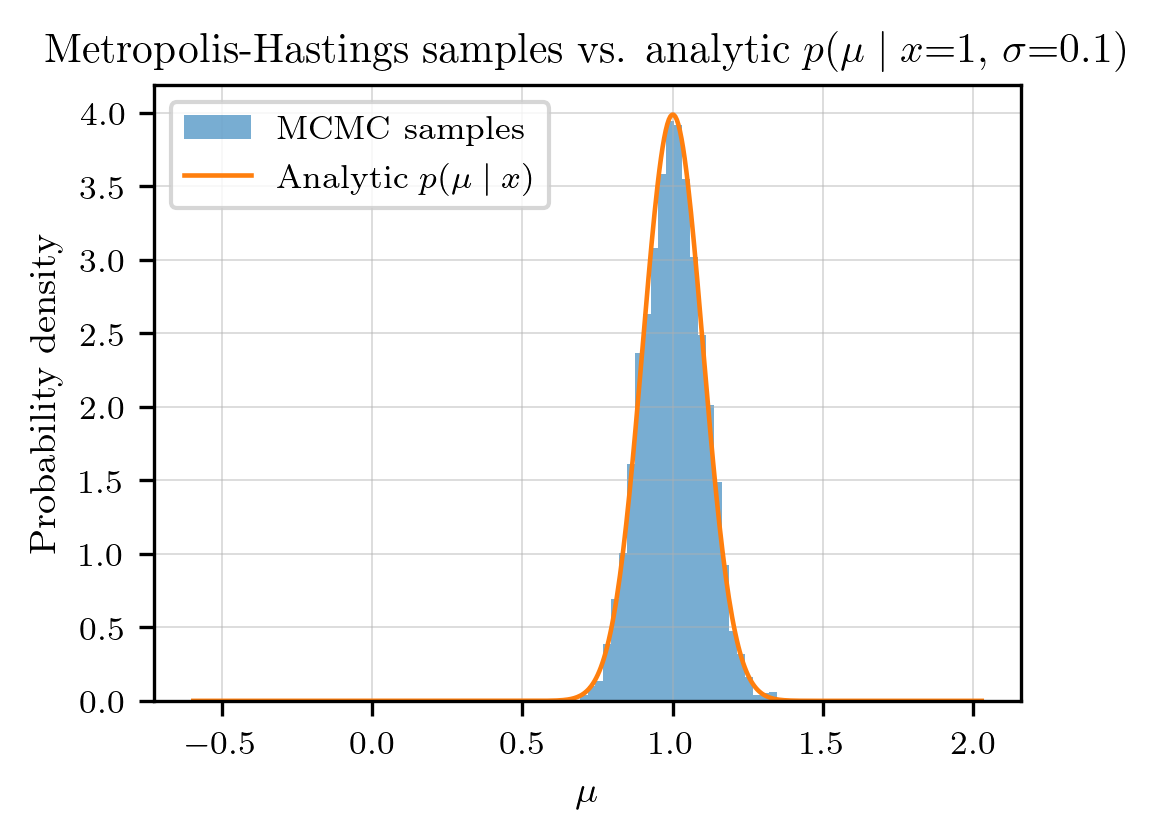

In [5]:
def analytic_pdf(mu):
    return np.exp(-0.5 * ((mu - x_obs) / sigma_obs) ** 2) / (sigma_obs * np.sqrt(2 * np.pi))


ax = plot_posterior(
    mh.samples,
    mh.param_labels,
    mh.n_burn,
    param_idx=0,
    pdf_fn=analytic_pdf,
)
ax.set_title(r"Metropolis-Hastings samples vs. analytic $p(\mu \mid x{=}1,\,\sigma{=}0.1)$")
plt.show()


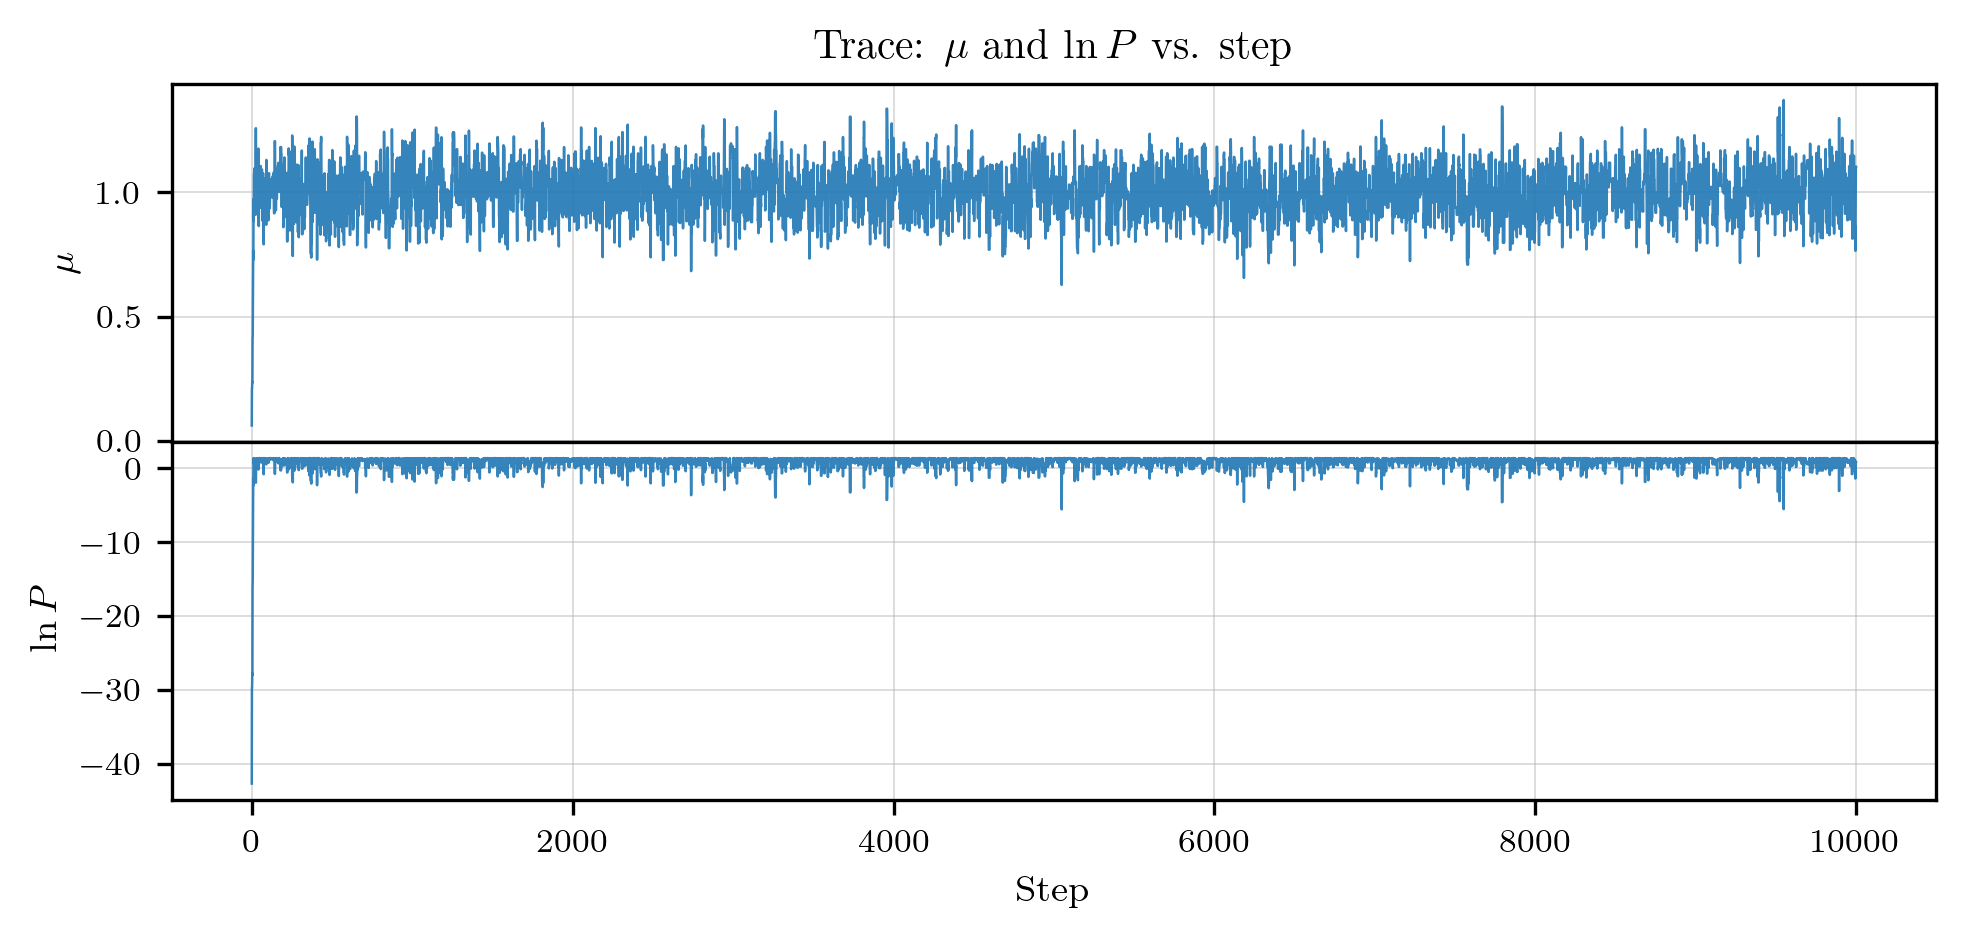

In [6]:
axes = plot_trace(
    mh.samples,
    mh.log_probs,
    mh.param_labels,
    mh.n_burn,
)
axes[0].set_title(r"Trace: $\mu$ and $\ln P$ vs. step")
plt.show()


The normalized histogram matches the analytic Gaussian posterior closely, and the sample mean and standard deviation are consistent with the exact result $\mu \sim \mathcal{N}(1.0, 0.1^2)$. Starting from $\mu_0 = 0$, the trace approaches the high-probability region near $\mu \approx 1$ within the first few hundred steps and then fluctuates around the correct posterior width. The $\ln P$ trace shows the same behavior: a rapid rise during the initial transient, followed by stationary fluctuations around the high-probability region. For this one-dimensional example, a proposal width of `0.20` is a reasonable compromise between moving far enough each step and keeping the acceptance fraction near `0.5`, and the trace does not show the obvious long plateaus that would signal severe autocorrelation.

The limitations of the exercise are important. This notebook keeps `n_burn = 0`, runs only one chain, and does not compute effective sample size, autocorrelation time, or any multi-chain convergence statistic. That is acceptable here because the target posterior is analytically known and the notebook is only validating the mechanics of the sampler. In a real analysis those omissions would be too weak for a publishable convergence argument: one would want lag-autocorrelation summaries, effective sample size, and multi-chain checks such as $\hat{R}$ before claiming the chain is genuinely well mixed.
